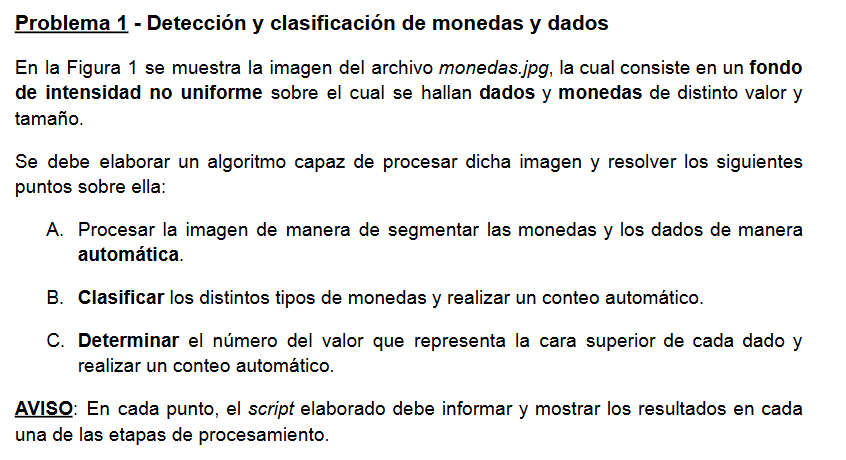

In [148]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# PARTE A

tecnica top-hat (PI_U6_Morfologico_pt_grises.py)

In [149]:
img_color = cv2.imread('img/monedas.jpg')
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

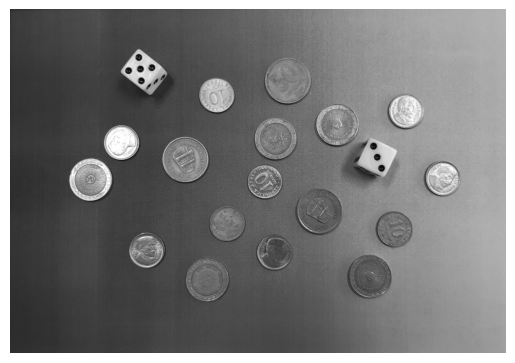

In [150]:
gray_blur = cv2.GaussianBlur(gray, (3, 3), 1)

plt.imshow(gray_blur, cmap='gray')
plt.axis('off')
plt.show()

usar top-hat para aplanar el fondo (PI_U6_Morfologico_pt_grises.py)

getStructuringElement:

cv2.MORPH_ELLIPSE: Le dice a OpenCV que la forma sea una elipse (un círculo). Elegimos esto porque tus objetos (las monedas) son redondos.

(35, 35): Este es el tamaño de la elipse (35x35 píxeles). Este tamaño es la clave: debe ser más grande que los objetos que quieres encontrar.

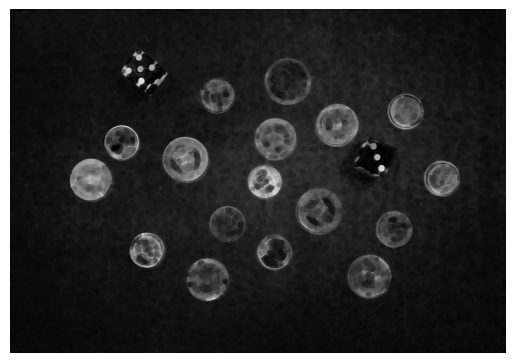

In [151]:
# Operaciones Top-Hat y Black-Hat
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))

# Top-Hat 
# Lo usamos para encontrar todos los objetos brillantes en la imagen que son más pequeños que el kernel.
tophat = cv2.morphologyEx(gray_blur, cv2.MORPH_TOPHAT, kernel)

# Black-Hat
# Lo usamos para encontrar todos los objetos oscuros en la imagen que son más pequeños que el kernel.
blackhat = cv2.morphologyEx(gray_blur, cv2.MORPH_BLACKHAT, kernel)

# combinar mascaras
# Obtiene una única imagen donde el fondo no uniforme ha sido completamente eliminado (es negro) y todos los objetos (brillantes y oscuros) están resaltados.
mask = cv2.add(tophat, blackhat)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

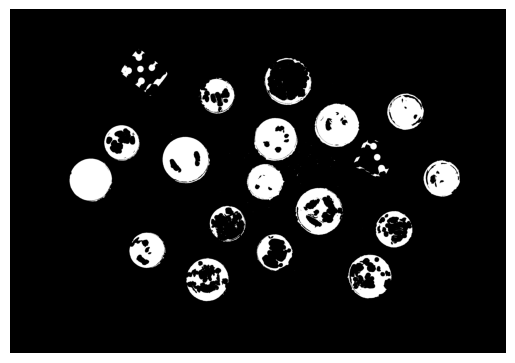

In [152]:
#umbralado
ret, mask_thresh = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(mask_thresh, cmap='gray')
plt.axis('off')
plt.show()

In [153]:
# componenes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_thresh, 8, cv2.CV_32S
) 

output_image = img_color.copy()
objetos_reales = 0

for i in range(1, num_labels): # Empezamos en 1 para saltar el fondo
    area = stats[i, cv2.CC_STAT_AREA]
    
    # filtramos objetos muy pequeños (ruido)
    if area < 8000: 
        continue
    
    objetos_reales += 1
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    (cX, cY) = centroids[i] 
    cv2.putText(output_image, str(i), (int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

print(f"Se encontraron {objetos_reales} objetos.")

Se encontraron 17 objetos.


(np.float64(-0.5), np.float64(3870.5), np.float64(2680.5), np.float64(-0.5))

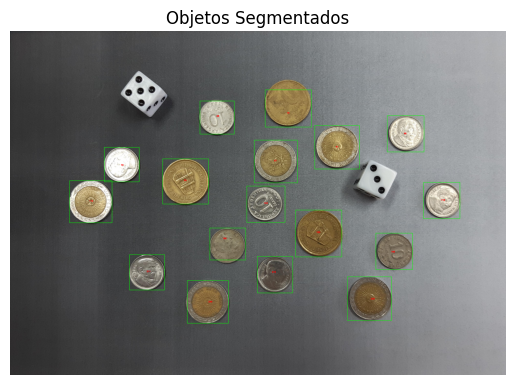

In [154]:
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('Objetos Segmentados')
plt.axis('off')

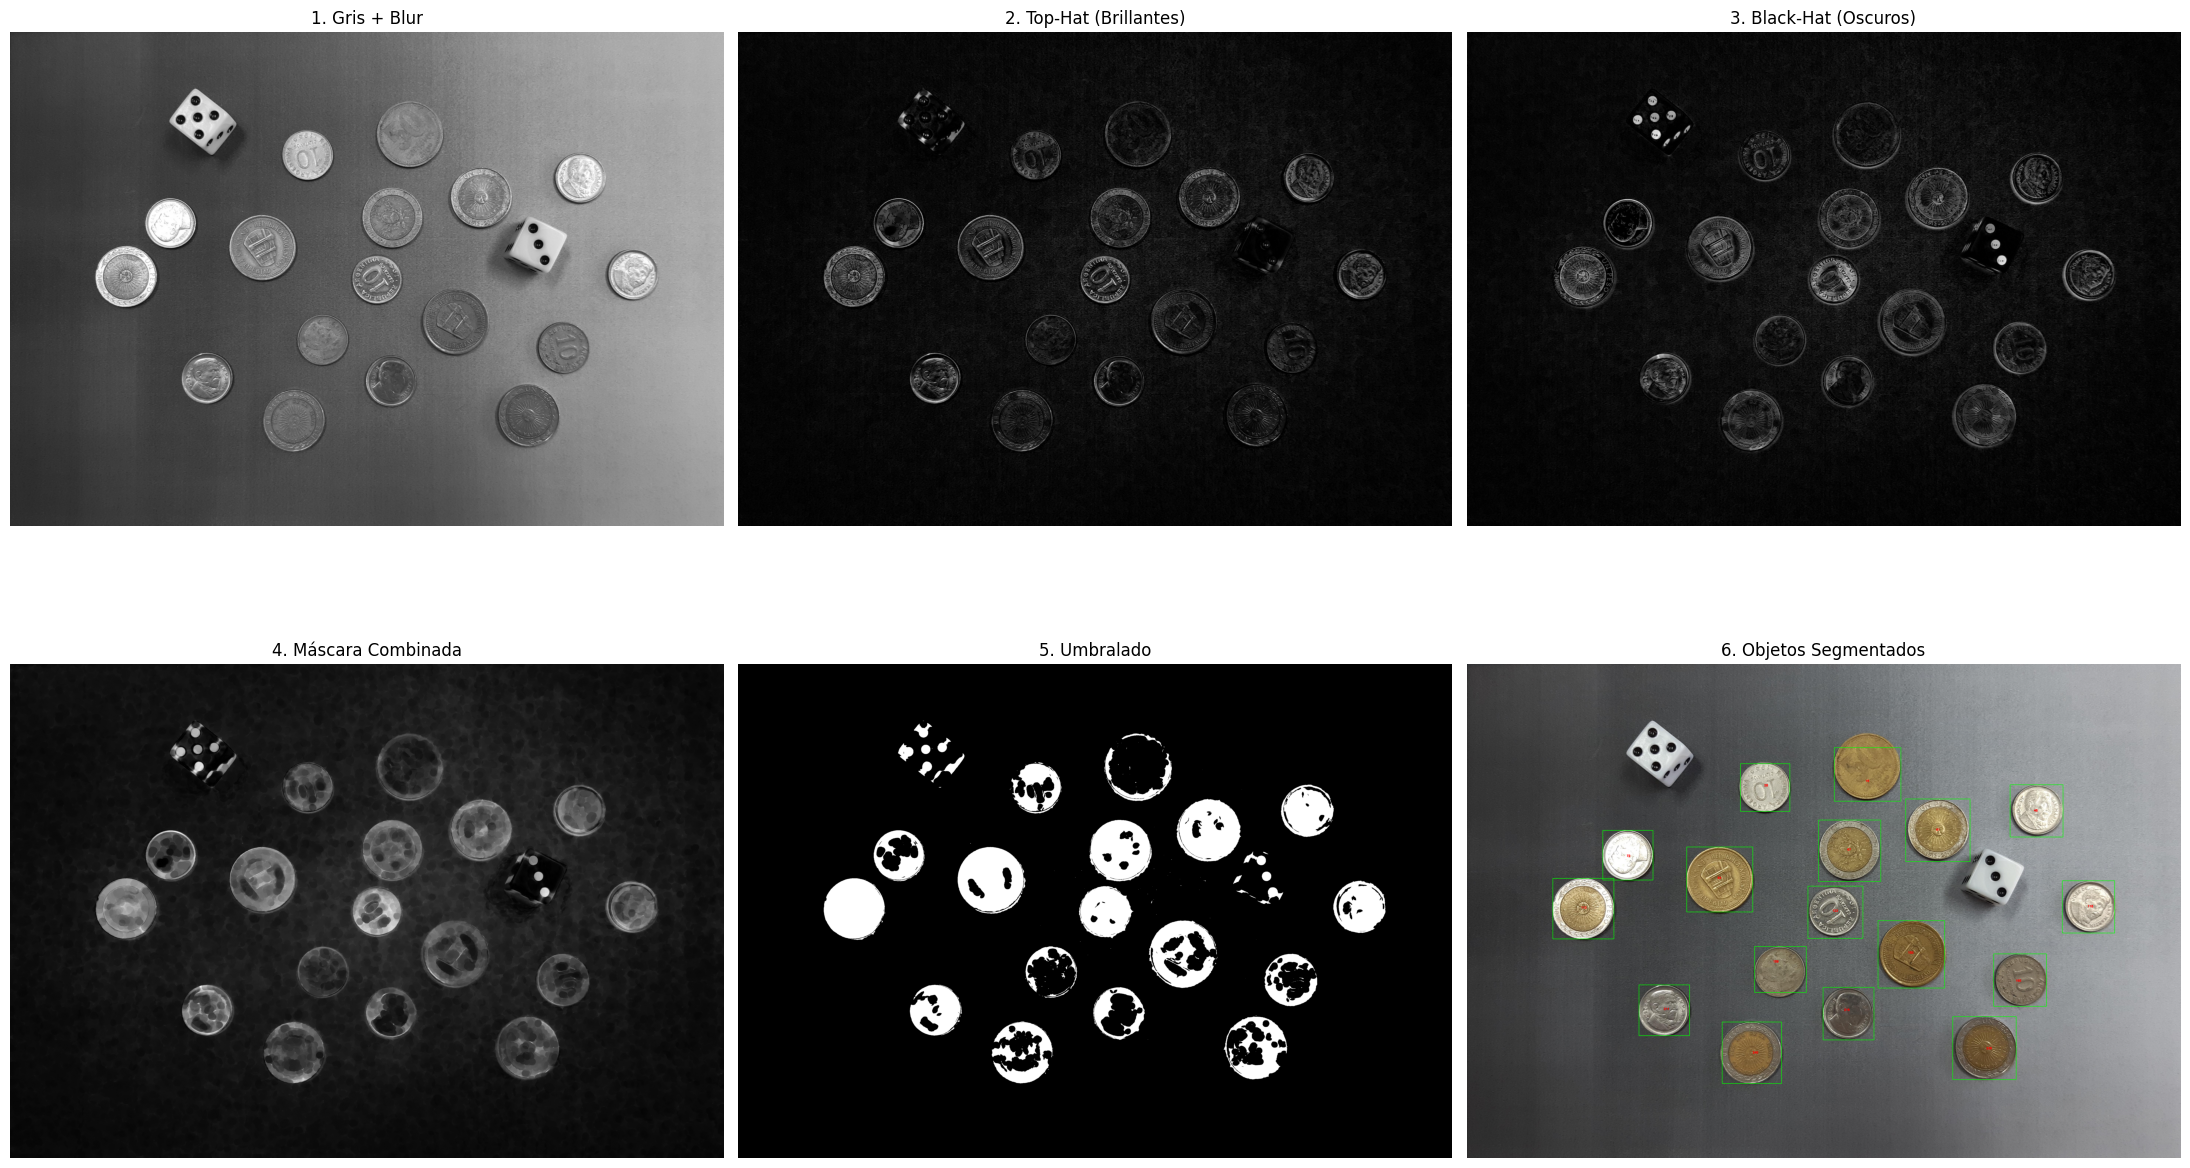

In [155]:
plt.figure(figsize=(22, 14))

plt.subplot(2, 3, 1)
plt.imshow(gray_blur, cmap='gray')
plt.title('1. Gris + Blur')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(tophat, cmap='gray')
plt.title('2. Top-Hat (Brillantes)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(blackhat, cmap='gray')
plt.title('3. Black-Hat (Oscuros)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title('4. Máscara Combinada')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(mask_thresh, cmap='gray')
plt.title('5. Umbralado')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('6. Objetos Segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()

Objeto #16: Área=18043, RGB=(133,111,71) -> Clasificado: Mediana Cobre
Objeto #28: Área=34990, RGB=(188,185,168) -> Clasificado: Mediana Plata
Objeto #48: Área=55301, RGB=(198,192,178) -> Clasificado: Mediana Plata
Objeto #61: Área=84206, RGB=(153,137,100) -> Clasificado: Grande Cobre
Objeto #67: Área=78925, RGB=(137,125,94) -> Clasificado: Grande Plata
Objeto #72: Área=33814, RGB=(213,211,204) -> Clasificado: Mediana Plata
Objeto #84: Área=89114, RGB=(158,134,83) -> Clasificado: Grande Cobre
Objeto #112: Área=84078, RGB=(193,179,149) -> Clasificado: Grande Plata
Objeto #118: Área=54979, RGB=(185,177,162) -> Clasificado: Mediana Plata
Objeto #123: Área=58320, RGB=(125,123,112) -> Clasificado: Mediana Plata
Objeto #150: Área=68541, RGB=(117,92,52) -> Clasificado: Mediana Cobre
Objeto #159: Área=12739, RGB=(117,109,90) -> Clasificado: Mediana Plata
Objeto #165: Área=29823, RGB=(112,102,87) -> Clasificado: Mediana Plata
Objeto #211: Área=47923, RGB=(134,130,121) -> Clasificado: Mediana Pl

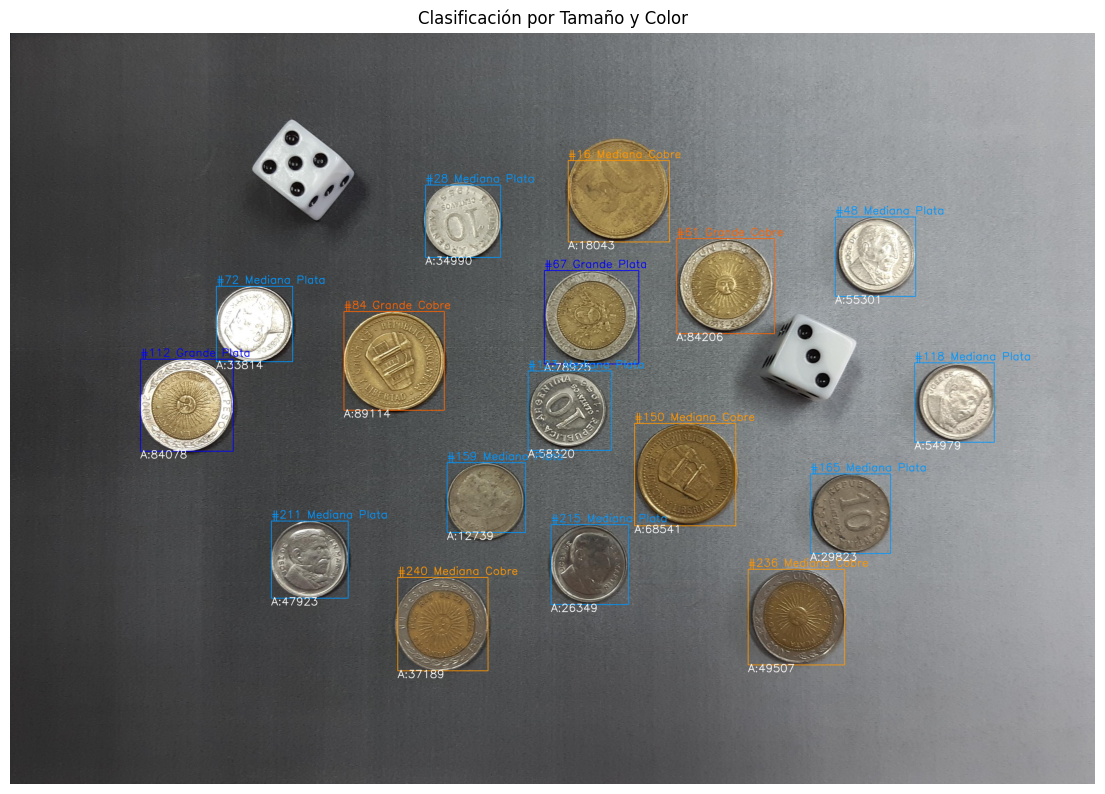

In [156]:
conteo_monedas = {
    "Grande Plata": 0,
    "Grande Cobre": 0,
    "Mediana Plata": 0,
    "Mediana Cobre": 0,
    "Chica Plata": 0,
    "Chica Cobre": 0
}

(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_thresh, 8, cv2.CV_32S
)

output_image = img_color.copy()
objetos_reales = 0

# CALIBRACIÓN DE TAMAÑOS
AREA_MINIMA = 12000           # Filtro de ruido
UMBRAL_LIMITE_CHICA = 12000   # Menor a esto es Chica
UMBRAL_LIMITE_MEDIANA = 77000 # Menor a esto es Mediana, Mayor es Grande

UMBRAL_COLOR_ROJO_VS_AZUL = 1.3 
UMBRAL_COLOR_ROJO_VS_VERDE = 1.1


for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]

    if area < AREA_MINIMA:
        continue

    objetos_reales += 1
    
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    
    if area < UMBRAL_LIMITE_CHICA:
        tipo_tamano = "Chica"
    elif area < UMBRAL_LIMITE_MEDIANA:
        tipo_tamano = "Mediana"
    else:
        tipo_tamano = "Grande"

    # Determinación de COLOR
    component_mask = (labels == i).astype("uint8") * 255
    mean_val = cv2.mean(img_color, mask=component_mask)
    B, G, R = mean_val[0], mean_val[1], mean_val[2]

    if R > B * UMBRAL_COLOR_ROJO_VS_AZUL and R > G * UMBRAL_COLOR_ROJO_VS_VERDE:
        tipo_color = "Cobre"
        if tipo_tamano == "Chica": color_box = (0, 200, 200) # Amarillo-anaranjado para Chica Cobre
        elif tipo_tamano == "Mediana": color_box = (0, 150, 255) # Naranja para Mediana Cobre
        else: color_box = (0, 100, 255) # Naranja oscuro para Grande Cobre
    else:
        tipo_color = "Plata"
        if tipo_tamano == "Chica": color_box = (150, 255, 150) # Verde claro para Chica Plata
        elif tipo_tamano == "Mediana": color_box = (255, 150, 0) # Azul claro para Mediana Plata
        else: color_box = (255, 0, 0) # Azul oscuro para Grande Plata

    clave = f"{tipo_tamano} {tipo_color}" 
    if clave in conteo_monedas:
        conteo_monedas[clave] += 1
    
    cv2.rectangle(output_image, (x, y), (x + w, y + h), color_box, 2)
    
    # Etiqueta ARRIBA: Tamaño y Color
    texto_etiqueta = f"#{i} {tipo_tamano} {tipo_color}"
    cv2.putText(output_image, texto_etiqueta, (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.3, color_box, 2)

    # Etiqueta ABAJO: Área exacta 
    texto_area = f"A:{int(area)}"
    cv2.putText(output_image, texto_area, (x, y + h + 25), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.3, (255, 255, 255), 2) 

    print(f"Objeto #{i}: Área={area}, RGB=({int(R)},{int(G)},{int(B)}) -> Clasificado: {clave}")

total_monedas_detectadas = 0
for tipo, cantidad in conteo_monedas.items():
    if cantidad > 0:
        print(f"- {tipo}: {cantidad}")
        total_monedas_detectadas += cantidad

print(f"\nTotal de objetos detectados: {total_monedas_detectadas}")

# Mostrar imagen con Matplotlib
plt.figure(figsize=(14, 12))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title("Clasificación por Tamaño y Color")
plt.axis('off')
plt.show()

#11 (Mediana Cobre) -> 50 Centavos
#16 (Mediana Plata) -> 10 Centavos
#24 (Mediana Plata) -> 10 Centavos
#28 (Grande Cobre) -> 50 Centavos
#29 (Grande Cobre) -> 50 Centavos
#31 (Mediana Plata) -> 10 Centavos
#36 (Grande Cobre) -> 50 Centavos
#50 (Grande Cobre) -> 50 Centavos
#53 (Mediana Plata) -> 10 Centavos
#56 (Mediana Plata) -> 10 Centavos
#68 (Grande Cobre) -> 50 Centavos
#73 (Mediana Plata) -> 10 Centavos
#75 (Mediana Plata) -> 10 Centavos
#90 (Mediana Plata) -> 10 Centavos
#92 (Mediana Plata) -> 10 Centavos
#99 (Mediana Cobre) -> 50 Centavos
#100 (Mediana Cobre) -> 50 Centavos
RESUMEN:
- 10 Centavos: 9 unidades
- 50 Centavos: 8 unidades


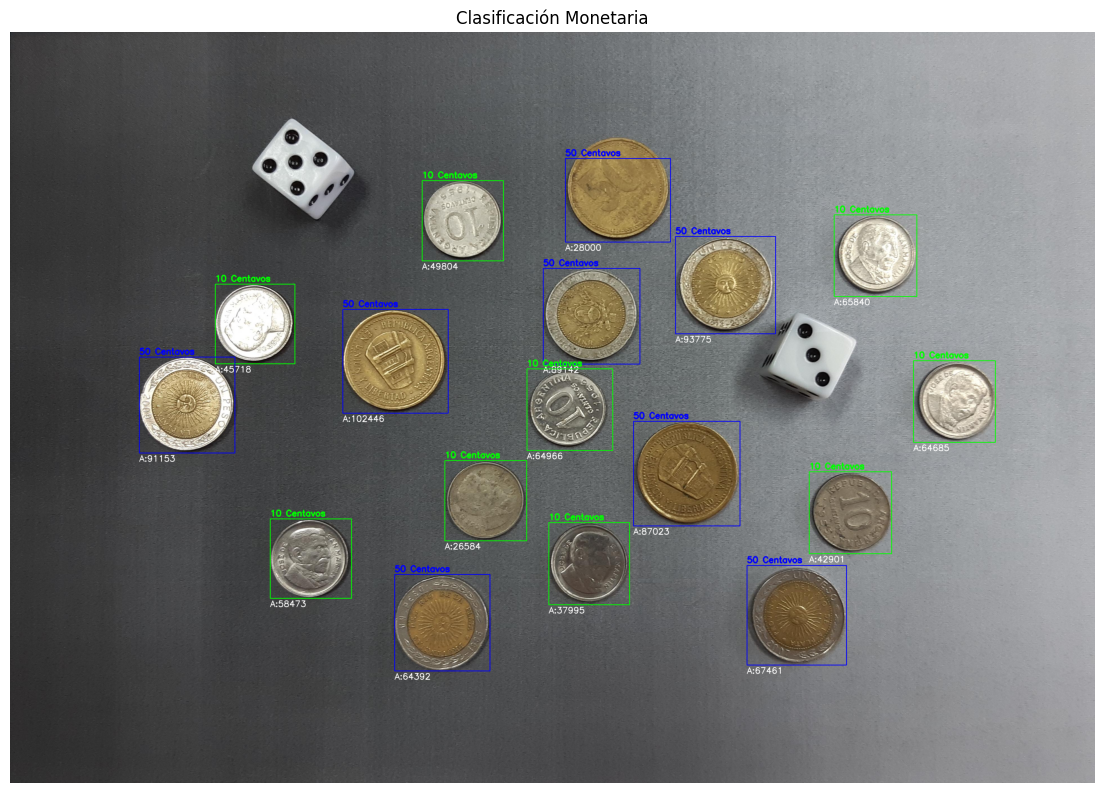

In [158]:
kernel = np.ones((5,5), np.uint8)
mask_thresh = cv2.morphologyEx(mask_thresh, cv2.MORPH_CLOSE, kernel)
mask_thresh = cv2.dilate(mask_thresh, kernel, iterations=1)

conteo_dinero = {
    "10 Centavos": 0,
    "50 Centavos": 0,
    "1 Peso": 0,
    "Desconocido": 0
}

(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_thresh, 8, cv2.CV_32S
)

output_image = img_color.copy()
objetos_reales = 0

# CALIBRACIÓN de tamaño
AREA_MINIMA = 12000
UMBRAL_LIMITE_CHICA = 12000   
UMBRAL_LIMITE_MEDIANA = 78000 

# Calibración de Color
UMBRAL_ROJO_VS_AZUL_ESTANDAR = 1.3
UMBRAL_ROJO_VS_VERDE = 1.1

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]

    if area < AREA_MINIMA:
        continue

    objetos_reales += 1
    
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    
    if area < UMBRAL_LIMITE_CHICA:
        tipo_tamano = "Chica"
    elif area < UMBRAL_LIMITE_MEDIANA:
        tipo_tamano = "Mediana"
    else:
        tipo_tamano = "Grande"

    component_mask = (labels == i).astype("uint8") * 255
    mean_val = cv2.mean(img_color, mask=component_mask)
    B, G, R = mean_val[0], mean_val[1], mean_val[2]

    if tipo_tamano == "Grande":
        umbral_actual = 1.1
    else:
        umbral_actual = UMBRAL_ROJO_VS_AZUL_ESTANDAR

    es_cobre = (R > B * umbral_actual) and (R > G * 1.05)

    if es_cobre:
        tipo_color = "Cobre"
    else:
        tipo_color = "Plata"


    etiqueta_valor = "Desconocido"
    color_box = (0, 255, 255) # Amarillo

    if tipo_tamano == "Mediana" and tipo_color == "Plata":
        etiqueta_valor = "10 Centavos"
        color_box = (0, 255, 0)   # Verde
        
    elif (tipo_tamano == "Grande" or tipo_tamano == "Mediana") and tipo_color == "Cobre":
        etiqueta_valor = "50 Centavos" 
        color_box = (255, 0, 0) # azul

    elif tipo_tamano == "Mediana" and tipo_color == "Plata":
        etiqueta_valor = "1 Peso"
        color_box = (255, 100, 0) # Azul Claro


    if etiqueta_valor in conteo_dinero:
        conteo_dinero[etiqueta_valor] += 1

    cv2.rectangle(output_image, (x, y), (x + w, y + h), color_box, 2)
    
    # Escribir VALOR REAL
    texto_etiqueta = f"{etiqueta_valor}"
    cv2.putText(output_image, texto_etiqueta, (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, color_box, 3)

    # Escribir Área
    texto_area = f"A:{int(area)}"
    cv2.putText(output_image, texto_area, (x, y + h + 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)

    print(f"#{i} ({tipo_tamano} {tipo_color}) -> {etiqueta_valor}")

print("RESUMEN:")
for valor, cantidad in conteo_dinero.items():
    if cantidad > 0:
        print(f"- {valor}: {cantidad} unidades")

plt.figure(figsize=(14, 12))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Clasificación Monetaria")
plt.show()